In [ ]:
from google.colab import drive
!pip install -q open3d

import os, sys, math, random
import numpy as np
import pandas as pd
import open3d as o3d
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib import cm

In [ ]:
drive.mount('/content/drive')

metadata_path = '/content/drive/MyDrive/ME 592/Project/Metadata.xlsx'
ply_folder    = '/content/drive/MyDrive/ME 592/Project/FielGrwon_ZeaMays_RawPCD_10k'
NUM_POINTS    = 10000 # Tested with 1024 and 10000 sample points as input to models
BATCH_SIZE    = 32
EPOCHS        = 100
SEED          = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
metadata = pd.read_excel(metadata_path)
metadata = metadata[metadata['NumLeaves'] <= 40].reset_index(drop=True)
print(f"Metadata filtered: {len(metadata)} valid entries retained.")

Metadata filtered: 1044 valid entries retained.


In [ ]:
all_paths, all_labels = [], []
for idx, row in metadata.iterrows():
    ply_path = os.path.join(ply_folder, f"{idx+1:04d}.ply")
    if os.path.exists(ply_path):
        all_paths.append(ply_path)
        all_labels.append(row['NumLeaves'])


In [ ]:
paths_tr, paths_tmp, y_tr, y_tmp = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=SEED)
paths_val, paths_te, y_val, y_te = train_test_split(
    paths_tmp, y_tmp, test_size=0.5, random_state=SEED)

In [ ]:
class MaizeCloud(Dataset):
    def __init__(self, paths, labels, train=True):
        self.paths  = paths
        self.labels = labels
        self.train  = train

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        pcd = o3d.io.read_point_cloud(self.paths[idx])
        pts = np.asarray(pcd.points, dtype=np.float32)
        pts -= pts.mean(0)
        pts /= (pts.std(0) + 1e-6)
        if self.train:
            theta = np.random.uniform(0, 2*np.pi)
            rot = np.array([[np.cos(theta), -np.sin(theta), 0],
                            [np.sin(theta),  np.cos(theta), 0],
                            [0,              0,             1]], dtype=np.float32)
            pts = pts @ rot.T
            pts += np.random.normal(scale=0.005, size=pts.shape).astype(np.float32)
        idxs = np.random.choice(pts.shape[0], NUM_POINTS, replace=pts.shape[0] < NUM_POINTS)
        pts = torch.from_numpy(pts[idxs])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return pts, label


In [ ]:
train_ds = MaizeCloud(paths_tr, y_tr, train=True)
val_ds   = MaizeCloud(paths_val, y_val, train=False)
test_ds  = MaizeCloud(paths_te, y_te, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [ ]:
class PointNetBlock(nn.Module):
    def __init__(self, in_c, mlp):
        super().__init__()
        layers = []
        c = in_c
        for k in mlp:
            layers += [nn.Conv1d(c, k, 1), nn.BatchNorm1d(k), nn.ReLU()]
            c = k
        self.mlp = nn.Sequential(*layers)

    def forward(self, x): return self.mlp(x)

class PointNetRegression(nn.Module):
    def __init__(self, in_c=3, mlp=[64,64,128], out_dim=1):
        super().__init__()
        self.feat = PointNetBlock(in_c, mlp)
        self.fc   = nn.Linear(mlp[-1], out_dim)

    def forward(self, x):
        x = x.transpose(2,1)
        x = self.feat(x)
        x = torch.max(x, 2)[0]
        return self.fc(x).squeeze(1)

In [ ]:
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
model    = PointNetRegression().to(device)
optimizer= optim.Adam(model.parameters(), lr=1e-3)
criterion= nn.MSELoss()

10000 points

In [ ]:
train_losses, val_losses = [], []
for epoch in range(1, EPOCHS+1):
    model.train(); running = 0
    for pts, lbl in train_loader:
        pts, lbl = pts.to(device), lbl.to(device)
        optimizer.zero_grad()
        loss = criterion(model(pts), lbl)
        loss.backward(); optimizer.step(); running += loss.item()
    train_losses.append(running / len(train_loader))

    model.eval(); vloss = 0
    with torch.no_grad():
        for pts, lbl in val_loader:
            pts, lbl = pts.to(device), lbl.to(device)
            vloss += criterion(model(pts), lbl).item()
    val_losses.append(vloss / len(val_loader))

    print(f"Epoch {epoch}/{EPOCHS} | Train {train_losses[-1]:.3f} | Val {val_losses[-1]:.3f}")

Epoch 1/100 | Train 34.932 | Val 19.534
Epoch 2/100 | Train 6.601 | Val 8.447
Epoch 3/100 | Train 5.359 | Val 5.829
Epoch 4/100 | Train 4.518 | Val 5.683
Epoch 5/100 | Train 4.286 | Val 5.270
Epoch 6/100 | Train 4.023 | Val 4.881
Epoch 7/100 | Train 3.971 | Val 4.478
Epoch 8/100 | Train 3.966 | Val 4.385
Epoch 9/100 | Train 3.869 | Val 4.258
Epoch 10/100 | Train 3.836 | Val 4.287
Epoch 11/100 | Train 3.914 | Val 4.146
Epoch 12/100 | Train 3.640 | Val 4.063
Epoch 13/100 | Train 3.715 | Val 4.575
Epoch 14/100 | Train 3.657 | Val 4.250
Epoch 15/100 | Train 4.020 | Val 4.009
Epoch 16/100 | Train 3.779 | Val 4.167
Epoch 17/100 | Train 3.636 | Val 4.517
Epoch 18/100 | Train 3.762 | Val 4.186
Epoch 19/100 | Train 3.843 | Val 4.183
Epoch 20/100 | Train 3.605 | Val 4.277
Epoch 21/100 | Train 3.587 | Val 4.267
Epoch 22/100 | Train 3.564 | Val 4.173
Epoch 23/100 | Train 3.606 | Val 4.230
Epoch 24/100 | Train 3.744 | Val 4.113
Epoch 25/100 | Train 3.434 | Val 4.434
Epoch 26/100 | Train 3.583 | Val

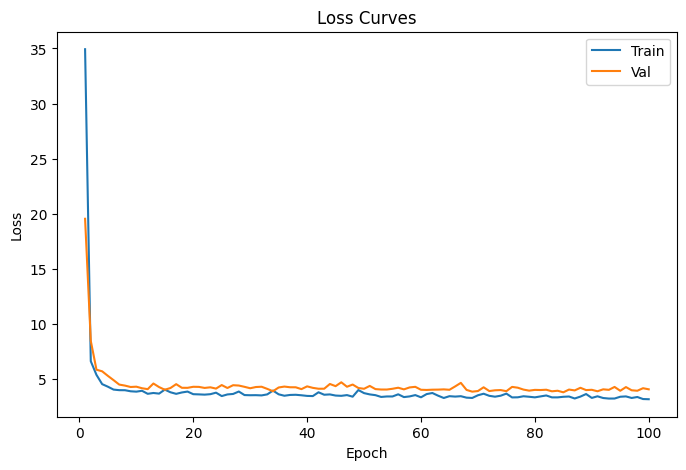

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train')
plt.plot(range(1, EPOCHS+1), val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves')
plt.legend(); plt.show()

MSE : 3.4571
RMSE: 1.8593
MAE : 1.4381
R²  : -0.0484


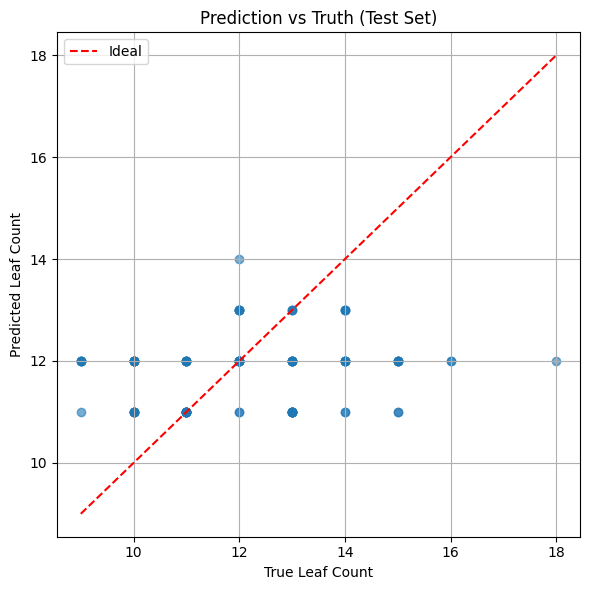

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()

all_preds, all_truth = [], []
with torch.no_grad():
    for pts, lbl in test_loader:
        pts = pts.to(device)
        preds = np.round(model(pts).cpu().numpy())
        all_preds.append(preds)
        all_truth.append(lbl.numpy())

# Flatten arrays
all_preds = np.concatenate(all_preds)
all_truth = np.concatenate(all_truth)

# --- Metrics ---
mse = mean_squared_error(all_truth, all_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_truth, all_preds)
r2 = r2_score(all_truth, all_preds)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

# --- Scatter Plot ---
plt.figure(figsize=(6,6))
plt.scatter(all_truth, all_preds, alpha=0.6)
plt.plot([all_truth.min(), all_truth.max()], [all_truth.min(), all_truth.max()], 'r--', label='Ideal')
plt.xlabel('True Leaf Count')
plt.ylabel('Predicted Leaf Count')
plt.title('Prediction vs Truth (Test Set)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


1024 points

In [ ]:
train_losses, val_losses = [], []
for epoch in range(1, EPOCHS+1):
    model.train(); running = 0
    for pts, lbl in train_loader:
        pts, lbl = pts.to(device), lbl.to(device)
        optimizer.zero_grad()
        loss = criterion(model(pts), lbl)
        loss.backward(); optimizer.step(); running += loss.item()
    train_losses.append(running / len(train_loader))

    model.eval(); vloss = 0
    with torch.no_grad():
        for pts, lbl in val_loader:
            pts, lbl = pts.to(device), lbl.to(device)
            vloss += criterion(model(pts), lbl).item()
    val_losses.append(vloss / len(val_loader))

    print(f"Epoch {epoch}/{EPOCHS} | Train {train_losses[-1]:.3f} | Val {val_losses[-1]:.3f}")

Epoch 1/10 | Train 36.041 | Val 18.216
Epoch 2/10 | Train 6.473 | Val 8.382
Epoch 3/10 | Train 5.437 | Val 6.016
Epoch 4/10 | Train 4.524 | Val 5.594
Epoch 5/10 | Train 4.337 | Val 5.396
Epoch 6/10 | Train 4.045 | Val 5.050
Epoch 7/10 | Train 3.959 | Val 4.451
Epoch 8/10 | Train 3.903 | Val 4.369
Epoch 9/10 | Train 3.911 | Val 4.379
Epoch 10/10 | Train 3.861 | Val 4.270


In [ ]:
model.eval(); tloss = 0
with torch.no_grad():
    for pts, lbl in test_loader:
        pts, lbl = pts.to(device), lbl.to(device)
        tloss += criterion(model(pts), lbl).item()
print(f"\nTest MSE: {tloss / len(test_loader):.3f}")


Test MSE: 3.555


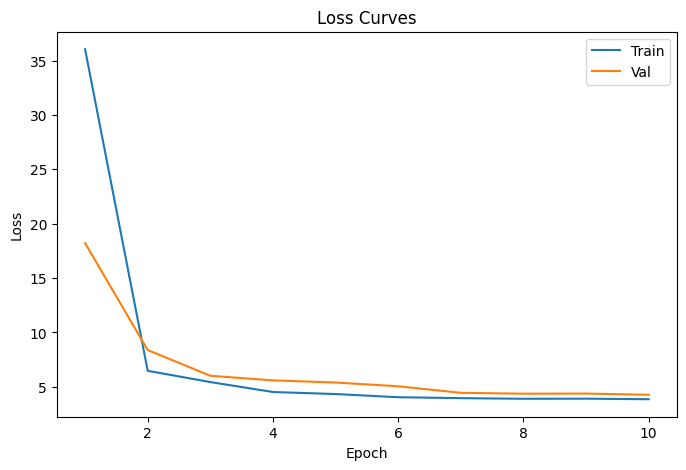

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train')
plt.plot(range(1, EPOCHS+1), val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves')
plt.legend(); plt.show()